In [5]:
%load_ext autoreload
%autoreload 2

In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scp
import datetime as dt
import sys
sys.path.append('/Users/tmelman/Documents/Projects/Serif Health DS interview/serifhealth_interview_tm_2026/src')
from standardize_csvs import standardize_csvs

In [11]:
standardize_csvs()

In [12]:
hpt = pd.read_csv('../data/hpt_processed.csv')
tic = pd.read_csv('../data/tic_processed.csv')

In [13]:
hpt.head()

,Unnamed: 0,payer_name,plan_name,code_type,raw_code,description,setting,modifiers,standard_charge_gross,standard_charge_discounted_cash,...,standard_charge_negotiated_percentage,standard_charge_min,standard_charge_max,standard_charge_methodology,additional_payer_notes,additional_generic_notes,date,code,payer,ein
0,0,Aetna,Medicare,CPT,99283,EMERGENCY DEPT VISIT LOW MDM,outpatient,NaN,NaN,NaN,...,NaN,83.78,1009.22,fee schedule,NaN,NaN,2024-07-01,99283,aetna,131740114
1,1,HealthFirst,Commercial Enrollees,CPT,43239,EGD BIOPSY SINGLE/MULTIPLE,outpatient,NaN,NaN,NaN,...,NaN,165.40,3206.34,fee schedule,NaN,NaN,2024-07-01,43239,healthfirst,131740114
2,2,Aetna,Commercial,CPT,43239,UPPER GI ENDOSCOPY BIOPSY,outpatient,NaN,NaN,NaN,...,NaN,1246.73,1394.79,fee schedule,NaN,NaN,2024-07-01,43239,aetna,131740114
3,3,Cigna,LocalPlus,CPT,99283,HC EMERGENCY DEPT VISIT LVL 3,outpatient,NaN,3744.0,2433.6,...,NaN,225.00,1797.00,other,NaN,per visit,2024-07-01,99283,cigna,131740114
4,4,Oscar,Medicare,CPT,43239,EGD BIOPSY SINGLE/MULTIPLE,outpatient,NaN,NaN,NaN,...,NaN,141.77,1815.10,fee schedule,NaN,NaN,2024-07-01,43239,oscar,131740114


In [14]:
tic.head()

,Unnamed: 0,payer,network_name,network_id,network_year_month,network_region,code,code_type,ein,taxonomy_filtered_npi_list,modifier_list,billing_class,place_of_service_list,negotiation_type,arrangement,rate,cms_baseline_schedule,cms_baseline_rate,date
0,0,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,872,MS-DRG,131740114,"1003990763,1023202793,1063525152,1063606739,10...",NaN,institutional,NaN,negotiated,ffs,15902.00,IPPS,6829.75,2025-01-01
1,1,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,99283,CPT,131624096,"1003255670,1245759711,1487026522,1598095267,16...",NaN,professional,11,negotiated,ffs,123.86,PFS_NONFACILITY_1320201,76.89,2025-01-01
2,2,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,43239,CPT,131740114,"1700348620,1700892056,1922539964,1942685292",NaN,professional,11,negotiated,ffs,993.92,PFS_NONFACILITY_1320202,424.76,2025-01-01
3,3,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,872,MS-DRG,133971298,"1245635200,1437523537,1528013695,1528432622,15...",NaN,institutional,NaN,negotiated,ffs,27924.63,IPPS,6829.75,2025-01-01
4,4,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,43239,CPT,131740114,1346697315,NaN,professional,11,negotiated,ffs,849.63,PFS_NONFACILITY_1320203,391.85,2025-01-01


In [39]:
# Merge columns

In [37]:
cols=['payer','code','code_type','ein']
merged = tic.iloc[:,1:].merge(hpt,on=cols,how='outer')

In [38]:
merged

,payer,network_name,network_id,network_year_month,network_region,code,code_type,ein,taxonomy_filtered_npi_list,modifier_list,...,standard_charge_gross,standard_charge_discounted_cash,standard_charge_negotiated_dollar,standard_charge_negotiated_percentage,standard_charge_min,standard_charge_max,standard_charge_methodology,additional_payer_notes,additional_generic_notes,date_y
0,1199,NaN,NaN,NaN,NaN,872,MS-DRG,131624096,NaN,NaN,...,NaN,13241.87,21238.60,NaN,6374.31,38357.42,case rate,NaN,NaN,2024-09-16
1,1199,NaN,NaN,NaN,NaN,872,MS-DRG,133971298,NaN,NaN,...,NaN,NaN,31739.33,NaN,NaN,NaN,Case Rate,Medicare Base Rate times Standard Inpatient We...,NaN,2025-01-01
2,1199,NaN,NaN,NaN,NaN,872,MS-DRG,133971298,NaN,NaN,...,NaN,NaN,31739.33,NaN,NaN,NaN,Case Rate,Medicare Base Rate times Standard Inpatient We...,NaN,2025-01-01
3,1199,NaN,NaN,NaN,NaN,43239,CPT,131624096,NaN,NaN,...,1800.00,1048.28,174.00,NaN,127.36,1257.93,Fee Schedule,NaN,NaN,2024-09-16
4,1199,NaN,NaN,NaN,NaN,43239,CPT,131624096,NaN,NaN,...,NaN,NaN,2719.00,NaN,2513.89,6438.00,case rate,NaN,NaN,2024-09-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5234,wellcare,NaN,NaN,NaN,NaN,99283,CPT,131740114,NaN,NaN,...,385.00,250.25,79.79,NaN,64.75,366.24,fee schedule,NaN,NaN,2024-07-01
5235,wellcare,NaN,NaN,NaN,NaN,99283,CPT,131740114,NaN,NaN,...,385.00,250.25,99.74,NaN,64.75,366.24,fee schedule,NaN,NaN,2024-07-01
5236,wellcare,NaN,NaN,NaN,NaN,99283,CPT,131740114,NaN,NaN,...,385.00,250.25,79.79,NaN,64.75,366.24,fee schedule,NaN,NaN,2024-07-01
5237,wellcare,NaN,NaN,NaN,NaN,99283,CPT,133971298,NaN,NaN,...,2182.13,414.60,326.60,NaN,NaN,NaN,Case Rate,100% of Medicare OPPS.,NaN,2025-01-01


In [40]:
merged.columns

Index(['payer', 'network_name', 'network_id', 'network_year_month',
       'network_region', 'code', 'code_type', 'ein',
       'taxonomy_filtered_npi_list', 'modifier_list', 'billing_class',
       'place_of_service_list', 'negotiation_type', 'arrangement', 'rate',
       'cms_baseline_schedule', 'cms_baseline_rate', 'date_x', 'Unnamed: 0',
       'payer_name', 'plan_name', 'raw_code', 'description', 'setting',
       'modifiers', 'standard_charge_gross', 'standard_charge_discounted_cash',
       'standard_charge_negotiated_dollar',
       'standard_charge_negotiated_percentage', 'standard_charge_min',
       'standard_charge_max', 'standard_charge_methodology',
       'additional_payer_notes', 'additional_generic_notes', 'date_y'],
      dtype='str')

In [ ]:
# Create confidence score
conf_score = lambda x: x['rate']/x['standard_charge_negotiated_dollar']

In [45]:
merged['conf_score'] = merged.apply(conf_score, axis=1)

In [47]:
merged.sort_values(by='conf_score',ascending=False)

,payer,network_name,network_id,network_year_month,network_region,code,code_type,ein,taxonomy_filtered_npi_list,modifier_list,...,standard_charge_discounted_cash,standard_charge_negotiated_dollar,standard_charge_negotiated_percentage,standard_charge_min,standard_charge_max,standard_charge_methodology,additional_payer_notes,additional_generic_notes,date_y,conf_score
120,aetna,open-access-managed-choice,39f0d406-b5df-4046-9759-f08565e45db7,202501.0,USA,43239,CPT,131740114,NaN,NaN,...,1163.50,157.52,NaN,146.49,1733.49,fee schedule,NaN,NaN,2024-07-01,73.006602
273,aetna,open-access-managed-choice,39f0d406-b5df-4046-9759-f08565e45db7,202501.0,USA,43239,CPT,131740114,"1235324534,1750528188,1811013824,1871834705,18...",NaN,...,1163.50,157.52,NaN,146.49,1733.49,fee schedule,NaN,NaN,2024-07-01,73.006602
115,aetna,open-access-managed-choice,39f0d406-b5df-4046-9759-f08565e45db7,202501.0,USA,43239,CPT,131740114,NaN,NaN,...,2551.25,157.52,NaN,146.49,1733.49,fee schedule,NaN,NaN,2024-07-01,73.006602
268,aetna,open-access-managed-choice,39f0d406-b5df-4046-9759-f08565e45db7,202501.0,USA,43239,CPT,131740114,"1235324534,1750528188,1811013824,1871834705,18...",NaN,...,2551.25,157.52,NaN,146.49,1733.49,fee schedule,NaN,NaN,2024-07-01,73.006602
394,aetna,open-access-managed-choice,39f0d406-b5df-4046-9759-f08565e45db7,202501.0,USA,43239,CPT,131740114,NaN,NaN,...,2551.25,157.52,NaN,146.49,1733.49,fee schedule,NaN,NaN,2024-07-01,69.832402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5234,wellcare,NaN,NaN,NaN,NaN,99283,CPT,131740114,NaN,NaN,...,250.25,79.79,NaN,64.75,366.24,fee schedule,NaN,NaN,2024-07-01,NaN
5235,wellcare,NaN,NaN,NaN,NaN,99283,CPT,131740114,NaN,NaN,...,250.25,99.74,NaN,64.75,366.24,fee schedule,NaN,NaN,2024-07-01,NaN
5236,wellcare,NaN,NaN,NaN,NaN,99283,CPT,131740114,NaN,NaN,...,250.25,79.79,NaN,64.75,366.24,fee schedule,NaN,NaN,2024-07-01,NaN
5237,wellcare,NaN,NaN,NaN,NaN,99283,CPT,133971298,NaN,NaN,...,414.60,326.60,NaN,NaN,NaN,Case Rate,100% of Medicare OPPS.,NaN,2025-01-01,NaN


<Axes: xlabel='conf_score', ylabel='Count'>

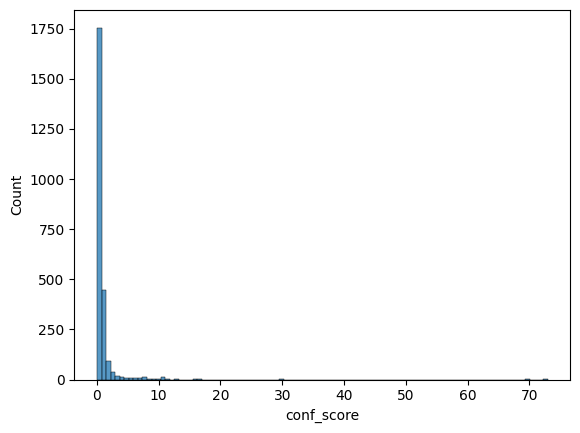

In [48]:
sns.histplot(merged['conf_score'])